In [4]:
#Create a data pipeline for this dataset 
#https://www.kaggle.com/datasets/sriharshaeedala/airline-delay/data

#which should include following
#Extract (load csv)
#Transform (clean data and transform data if needed)
#Load (save the cleaned data in csv file)
#Also create visualization of 
#correlation of attributes
#distribution of values in attributes 
#and any 3 other graph using seaborn 
#Note: Also generate insight from it and explain it. 

#Submission should be done in github repo with ipynb file or google collab link.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
df_raw = pd.read_csv('Airline_Delay_Cause.csv')

print(f"✅ Dataset loaded!")
print(f"   Rows    : {df_raw.shape[0]:,}")
print(f"   Columns : {df_raw.shape[1]}")
print("\n--- First 5 Rows ---")
print(df_raw.head())


✅ Dataset loaded!
   Rows    : 171,666
   Columns : 21

--- First 5 Rows ---
   year  month carrier       carrier_name airport  \
0  2023      8      9E  Endeavor Air Inc.     ABE   
1  2023      8      9E  Endeavor Air Inc.     ABY   
2  2023      8      9E  Endeavor Air Inc.     AEX   
3  2023      8      9E  Endeavor Air Inc.     AGS   
4  2023      8      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         89.0       13.0   
1             Albany, GA: Southwest Georgia Regional         62.0       10.0   
2           Alexandria, LA: Alexandria International         62.0       10.0   
3        Augusta, GA: Augusta Regional at Bush Field         66.0       12.0   
4                   Albany, NY: Albany International         92.0       22.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        2.25        1.60  ...          0.0

In [8]:
print("=== COLUMN NAMES ===")
print(df_raw.columns.tolist())

print("\n=== DATA TYPES ===")
print(df_raw.dtypes)

print("\n=== BASIC STATISTICS ===")
print(df_raw.describe())

=== COLUMN NAMES ===
['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

=== DATA TYPES ===
year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
d

In [9]:
df = df_raw.copy()  # Always work on a copy — never touch the original!

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_pct
}).sort_values('Missing %', ascending=False)

print("=== MISSING VALUES REPORT ===")
print(missing_report[missing_report['Missing Count'] > 0])
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

=== MISSING VALUES REPORT ===
                     Missing Count  Missing %
arr_del15                      443       0.26
nas_ct                         240       0.14
security_ct                    240       0.14
security_delay                 240       0.14
nas_delay                      240       0.14
weather_delay                  240       0.14
carrier_delay                  240       0.14
arr_delay                      240       0.14
arr_diverted                   240       0.14
arr_cancelled                  240       0.14
late_aircraft_ct               240       0.14
late_aircraft_delay            240       0.14
weather_ct                     240       0.14
carrier_ct                     240       0.14
arr_flights                    240       0.14

Total missing cells: 3803


In [10]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

df[num_cols] = df[num_cols].fillna(0)
df[cat_cols] = df[cat_cols].fillna('Unknown')

print(f"Missing values remaining after fix: {df.isnull().sum().sum()}")
print("✅ Missing values handled!")

Missing values remaining after fix: 0
✅ Missing values handled!


In [11]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Rows before : {before:,}")
print(f"Rows after  : {after:,}")
print(f"Duplicates removed: {before - after}")
print("✅ Duplicates handled!")


Rows before : 171,666
Rows after  : 171,666
Duplicates removed: 0
✅ Duplicates handled!


In [12]:
df['year']  = df['year'].astype(int)
df['month'] = df['month'].astype(int)

# Create a readable month name column
month_map = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
df['month_name'] = df['month'].map(month_map)

# Create a date column (year + month)
df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2),
    format='%Y-%m'
)

print("✅ Data types fixed!")
print(df[['year', 'month', 'month_name', 'date']].head())

✅ Data types fixed!
   year  month month_name       date
0  2023      8        Aug 2023-08-01
1  2023      8        Aug 2023-08-01
2  2023      8        Aug 2023-08-01
3  2023      8        Aug 2023-08-01
4  2023      8        Aug 2023-08-01


In [18]:
df['delay_rate'] = np.where(
    df['arr_flights'] > 0,
    (df['arr_del15'] / df['arr_flights'] * 100).round(2),
    0
)

# 2) Average delay per delayed flight (in minutes)
df['avg_delay_min'] = np.where(
    df['arr_del15'] > 0,
    (df['arr_delay'] / df['arr_del15']).round(2),
    0
)

# 3) Cancellation Rate
df['cancel_rate'] = np.where(
    df['arr_flights'] > 0,
    (df['arr_cancelled'] / df['arr_flights'] * 100).round(2),
    0
)

cause_cols = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
cause_labels = {
    'carrier_ct'      : 'Carrier',
    'weather_ct'      : 'Weather',
    'nas_ct'          : 'NAS',
    'security_ct'     : 'Security',
    'late_aircraft_ct': 'Late Aircraft'
}
df['dominant_cause'] = df[cause_cols].idxmax(axis=1).map(cause_labels)

print("✅ Feature Engineering Done! New columns added:")
print("   delay_rate, avg_delay_min, cancel_rate, dominant_cause")
print(df[['carrier_name', 'delay_rate', 'avg_delay_min', 'cancel_rate', 'dominant_cause']].head(8))

✅ Feature Engineering Done! New columns added:
   delay_rate, avg_delay_min, cancel_rate, dominant_cause
        carrier_name  delay_rate  avg_delay_min  cancel_rate dominant_cause
0  Endeavor Air Inc.       14.61         105.77         2.25  Late Aircraft
1  Endeavor Air Inc.       16.13          79.90         0.00  Late Aircraft
2  Endeavor Air Inc.       16.13          76.60         1.61  Late Aircraft
3  Endeavor Air Inc.       18.18         116.42         1.52            NAS
4  Endeavor Air Inc.       23.91          69.55         2.17  Late Aircraft
5  Endeavor Air Inc.       15.65         116.28         1.96  Late Aircraft
6  Endeavor Air Inc.       16.00          70.25         0.00        Carrier
7  Endeavor Air Inc.       11.86          46.29         3.39        Carrier


In [19]:
output_file = 'airline_delay_cleaned.csv'
df.to_csv(output_file, index=False)

# Verify it saved correctly
df_check = pd.read_csv(output_file)
print(f"✅ Cleaned data saved to '{output_file}'")
print(f"   Saved rows    : {df_check.shape[0]:,}")
print(f"   Saved columns : {df_check.shape[1]}")



✅ Cleaned data saved to 'airline_delay_cleaned.csv'
   Saved rows    : 171,666
   Saved columns : 27


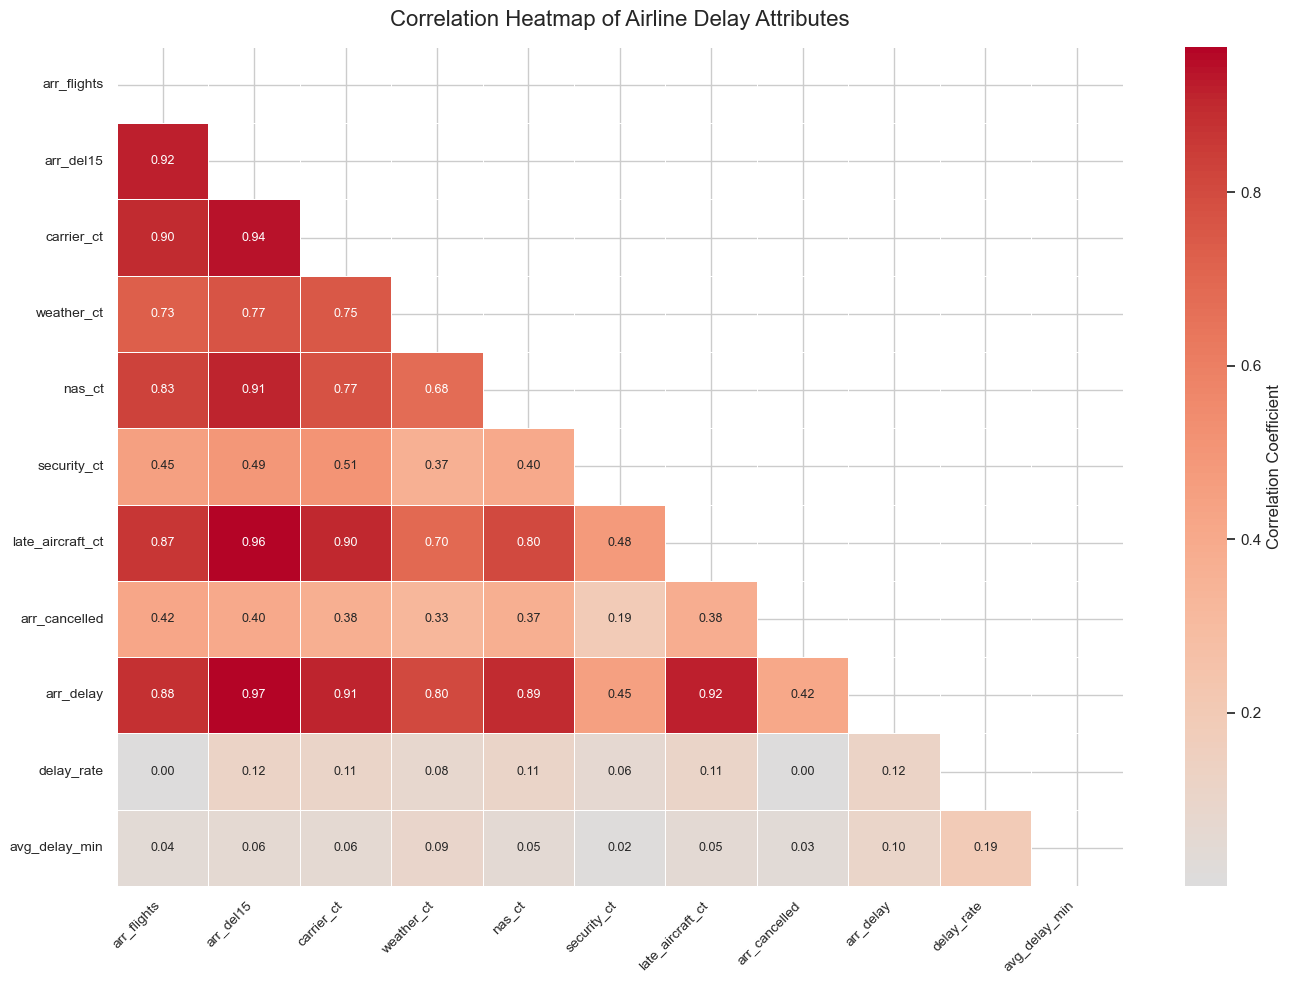


📌 INSIGHT — Correlation Heatmap:
  • arr_del15 is highly correlated with arr_delay & late_aircraft_ct.
  • security_ct has near-zero correlation — security delays are rare & independent.
  • arr_flights correlates with arr_cancelled — busier airports cancel more flights.


In [20]:
corr_cols = [
    'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct',
    'nas_ct', 'security_ct', 'late_aircraft_ct',
    'arr_cancelled', 'arr_delay', 'delay_rate', 'avg_delay_min'
]

corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9},
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap of Airline Delay Attributes', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('plot_1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT — Correlation Heatmap:")
print("  • arr_del15 is highly correlated with arr_delay & late_aircraft_ct.")
print("  • security_ct has near-zero correlation — security delays are rare & independent.")
print("  • arr_flights correlates with arr_cancelled — busier airports cancel more flights.")


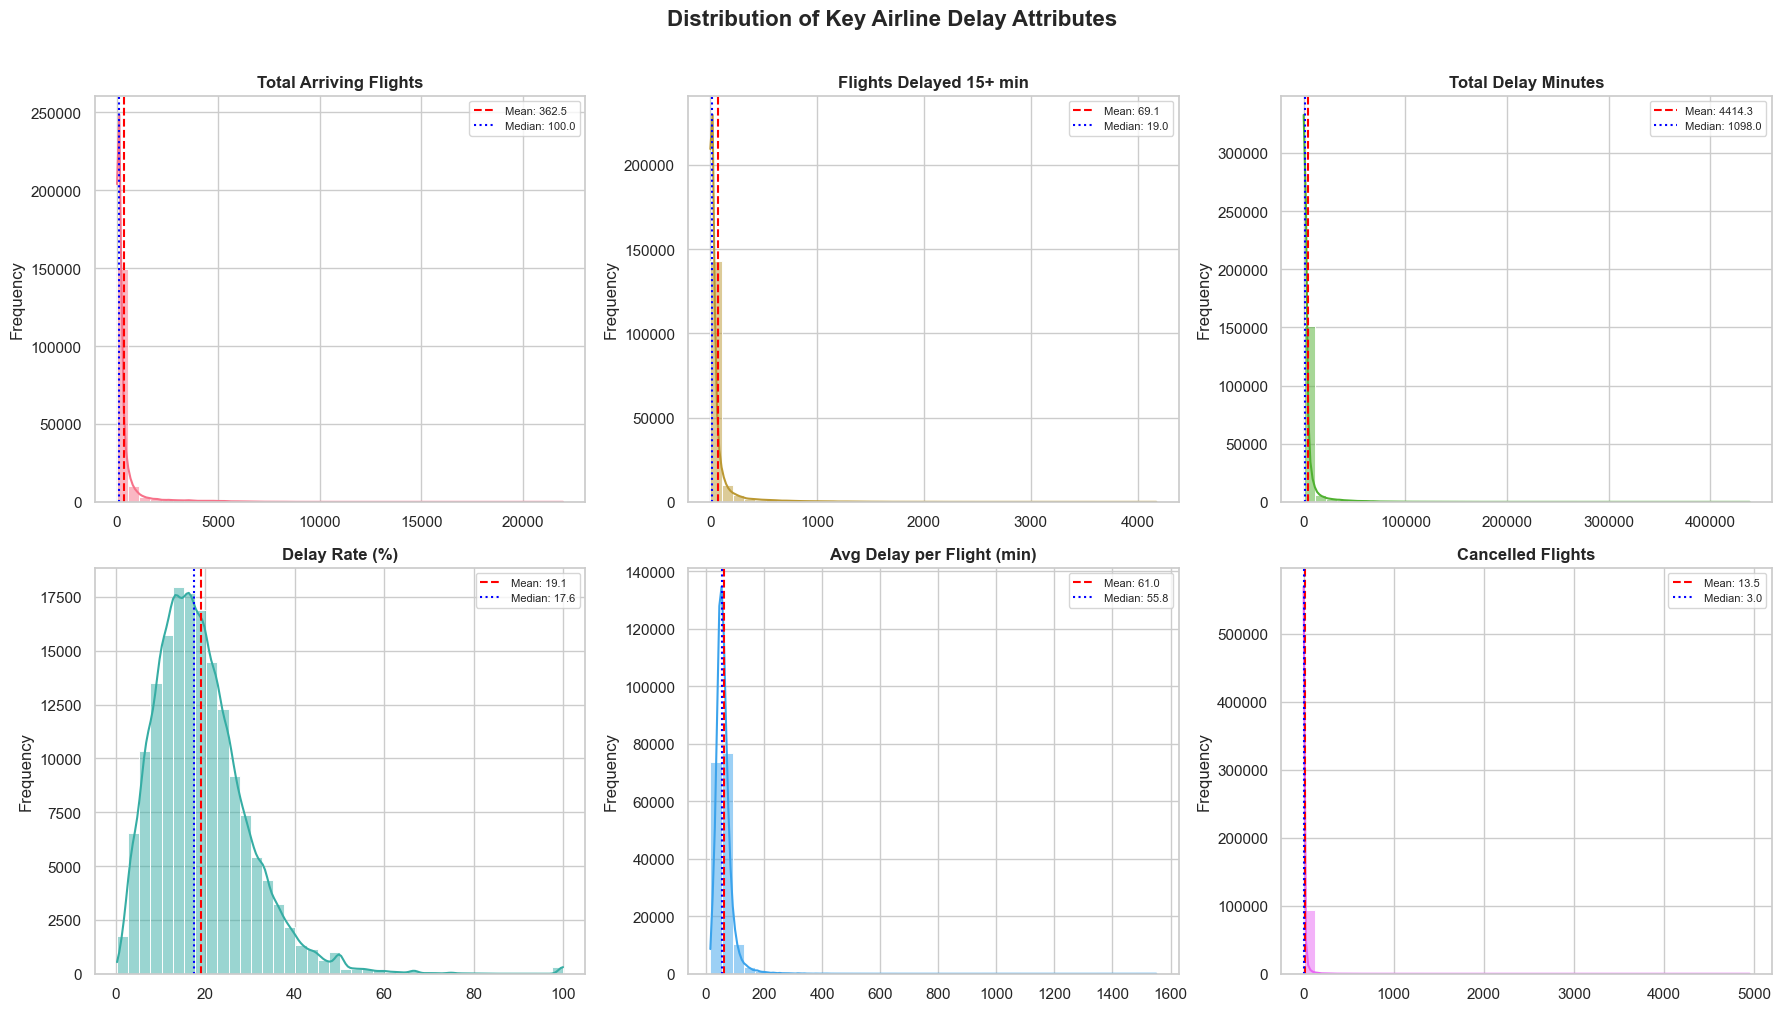


📌 INSIGHT — Distributions:
  • All distributions are RIGHT-SKEWED — most flights have low delay,
    but a small number have extreme delays (outliers).
  • Delay rate typically sits between 15–30% for most records.
  • Average delay per flight peaks around 35–60 minutes.


In [22]:
dist_cols = [
    ('arr_flights',  'Total Arriving Flights'),
    ('arr_del15',    'Flights Delayed 15+ min'),
    ('arr_delay',    'Total Delay Minutes'),
    ('delay_rate',   'Delay Rate (%)'),
    ('avg_delay_min','Avg Delay per Flight (min)'),
    ('arr_cancelled','Cancelled Flights')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette = sns.color_palette('husl', 6)

for i, (col, label) in enumerate(dist_cols):
    data = df[col][df[col] > 0]  # exclude zeros for better distribution view
    sns.histplot(data, ax=axes[i], kde=True, color=palette[i], bins=40, edgecolor='white')
    axes[i].axvline(data.mean(),   color='red',  linestyle='--', linewidth=1.5,
                    label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='blue', linestyle=':',  linewidth=1.5,
                    label=f'Median: {data.median():.1f}')
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Key Airline Delay Attributes', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT — Distributions:")
print("  • All distributions are RIGHT-SKEWED — most flights have low delay,")
print("    but a small number have extreme delays (outliers).")
print("  • Delay rate typically sits between 15–30% for most records.")
print("  • Average delay per flight peaks around 35–60 minutes.")



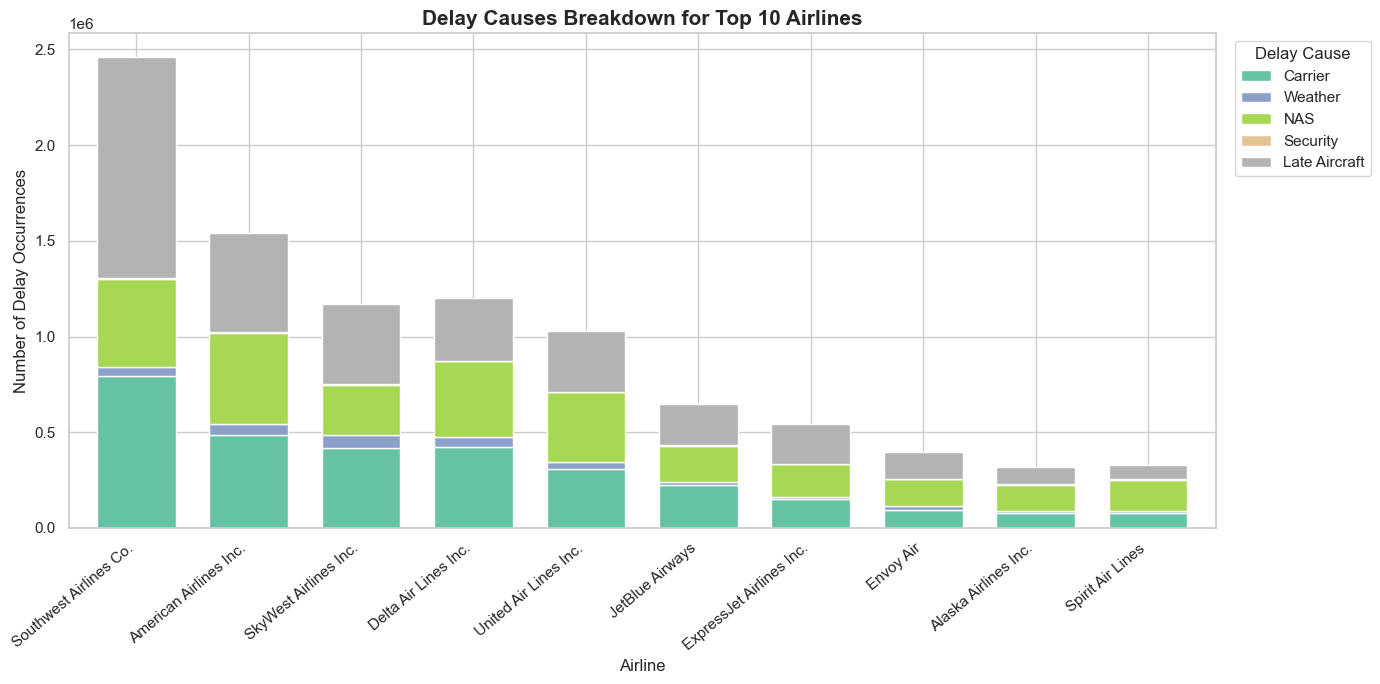


📌 INSIGHT — Stacked Bar Chart:
  • 'Late Aircraft' & 'NAS' are the TOP two causes across ALL airlines.
  • 'Security' is almost invisible — a very rare cause of delay.
  • 'Weather' varies — airlines with hubs in stormy regions are more affected.


In [23]:
top_carriers = df.groupby('carrier_name')['arr_del15'].sum().nlargest(10).index
df_top = df[df['carrier_name'].isin(top_carriers)]

cause_by_carrier = df_top.groupby('carrier_name')[cause_cols].sum()
cause_by_carrier.columns = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']
cause_by_carrier = cause_by_carrier.sort_values('Late Aircraft', ascending=False)

cause_by_carrier.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='Set2',
    edgecolor='white',
    width=0.7
)

plt.title('Delay Causes Breakdown for Top 10 Airlines', fontsize=15, fontweight='bold')
plt.xlabel('Airline', fontsize=12)
plt.ylabel('Number of Delay Occurrences', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.legend(title='Delay Cause', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_3_delay_causes_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT — Stacked Bar Chart:")
print("  • 'Late Aircraft' & 'NAS' are the TOP two causes across ALL airlines.")
print("  • 'Security' is almost invisible — a very rare cause of delay.")
print("  • 'Weather' varies — airlines with hubs in stormy regions are more affected.")


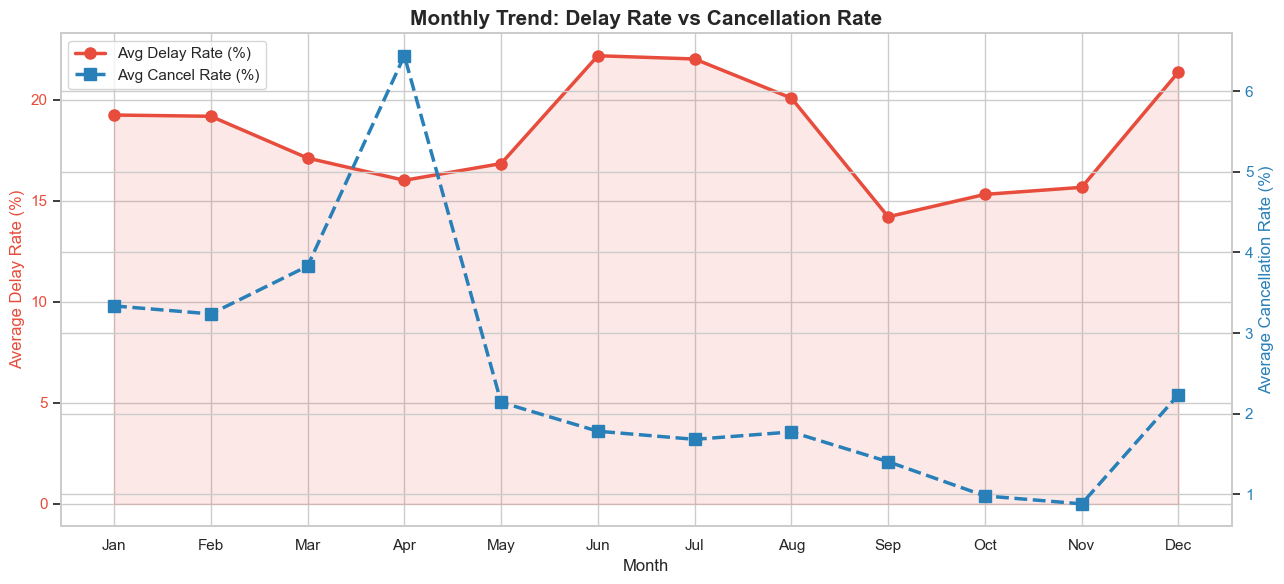


📌 INSIGHT — Monthly Trend:
  • Delays PEAK in June–July (summer travel rush) & December (holiday season).
  • Cancellations are HIGHEST in Jan–Feb due to winter snowstorms.
  • September–October = BEST months to fly (lowest delays & cancellations).


In [24]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_delay  = df.groupby('month_name')['delay_rate'].mean().reindex(month_order)
monthly_cancel = df.groupby('month_name')['cancel_rate'].mean().reindex(month_order)

fig, ax1 = plt.subplots(figsize=(13, 6))

# Delay rate — left axis
ax1.plot(month_order, monthly_delay.values,
         color='#e74c3c', linewidth=2.5, marker='o', markersize=8, label='Avg Delay Rate (%)')
ax1.fill_between(range(12), monthly_delay.values, alpha=0.12, color='#e74c3c')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Average Delay Rate (%)', color='#e74c3c', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#e74c3c')
ax1.set_xticks(range(12))
ax1.set_xticklabels(month_order)

# Cancellation rate — right axis
ax2 = ax1.twinx()
ax2.plot(month_order, monthly_cancel.values,
         color='#2980b9', linewidth=2.5, marker='s', markersize=8,
         linestyle='--', label='Avg Cancel Rate (%)')
ax2.set_ylabel('Average Cancellation Rate (%)', color='#2980b9', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#2980b9')

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.title('Monthly Trend: Delay Rate vs Cancellation Rate', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_4_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT — Monthly Trend:")
print("  • Delays PEAK in June–July (summer travel rush) & December (holiday season).")
print("  • Cancellations are HIGHEST in Jan–Feb due to winter snowstorms.")
print("  • September–October = BEST months to fly (lowest delays & cancellations).")


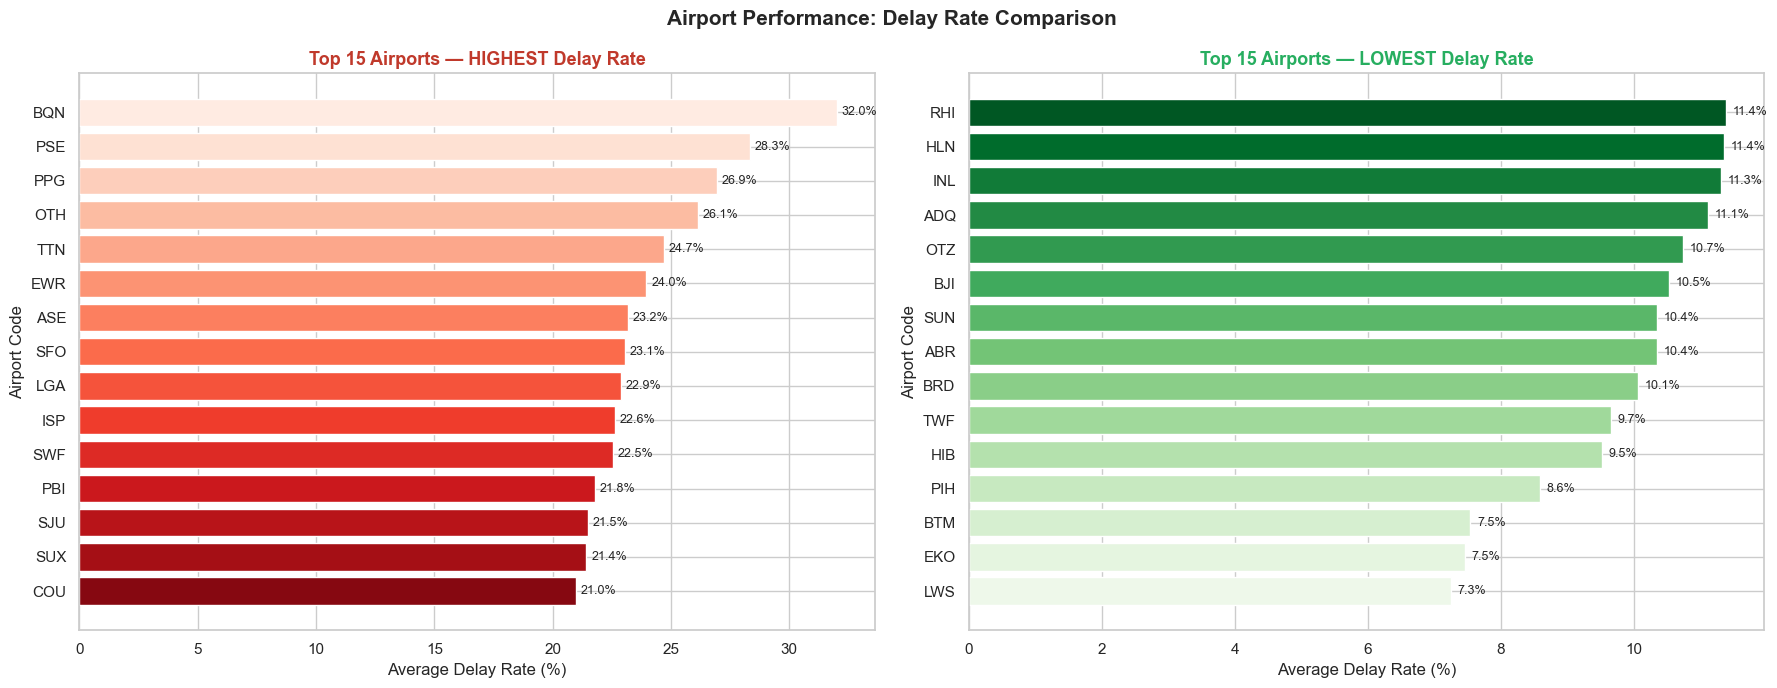


📌 INSIGHT — Airport Rankings:
  • Small regional airports tend to have the WORST delay rates.
  • Major hub airports often perform better due to more resources & flexibility.
  • Airports in mild-climate regions show consistently lower delay rates.


In [25]:
airport_counts   = df['airport'].value_counts()
valid_airports   = airport_counts[airport_counts >= 100].index

airport_delay = (
    df[df['airport'].isin(valid_airports)]
    .groupby('airport')['delay_rate']
    .mean()
    .sort_values(ascending=False)
)

top_worst = airport_delay.head(15)
top_best  = airport_delay.tail(15).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Worst airports
bars1 = ax1.barh(top_worst.index[::-1], top_worst.values[::-1],
                  color=sns.color_palette('Reds_r', 15), edgecolor='white')
ax1.set_title('Top 15 Airports — HIGHEST Delay Rate', fontsize=13, fontweight='bold', color='#c0392b')
ax1.set_xlabel('Average Delay Rate (%)')
ax1.set_ylabel('Airport Code')
for bar, val in zip(bars1, top_worst.values[::-1]):
    ax1.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

# Best airports
bars2 = ax2.barh(top_best.index, top_best.values,
                  color=sns.color_palette('Greens', 15), edgecolor='white')
ax2.set_title('Top 15 Airports — LOWEST Delay Rate', fontsize=13, fontweight='bold', color='#27ae60')
ax2.set_xlabel('Average Delay Rate (%)')
ax2.set_ylabel('Airport Code')
for bar, val in zip(bars2, top_best.values):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Airport Performance: Delay Rate Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_5_airport_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT — Airport Rankings:")
print("  • Small regional airports tend to have the WORST delay rates.")
print("  • Major hub airports often perform better due to more resources & flexibility.")
print("  • Airports in mild-climate regions show consistently lower delay rates.")


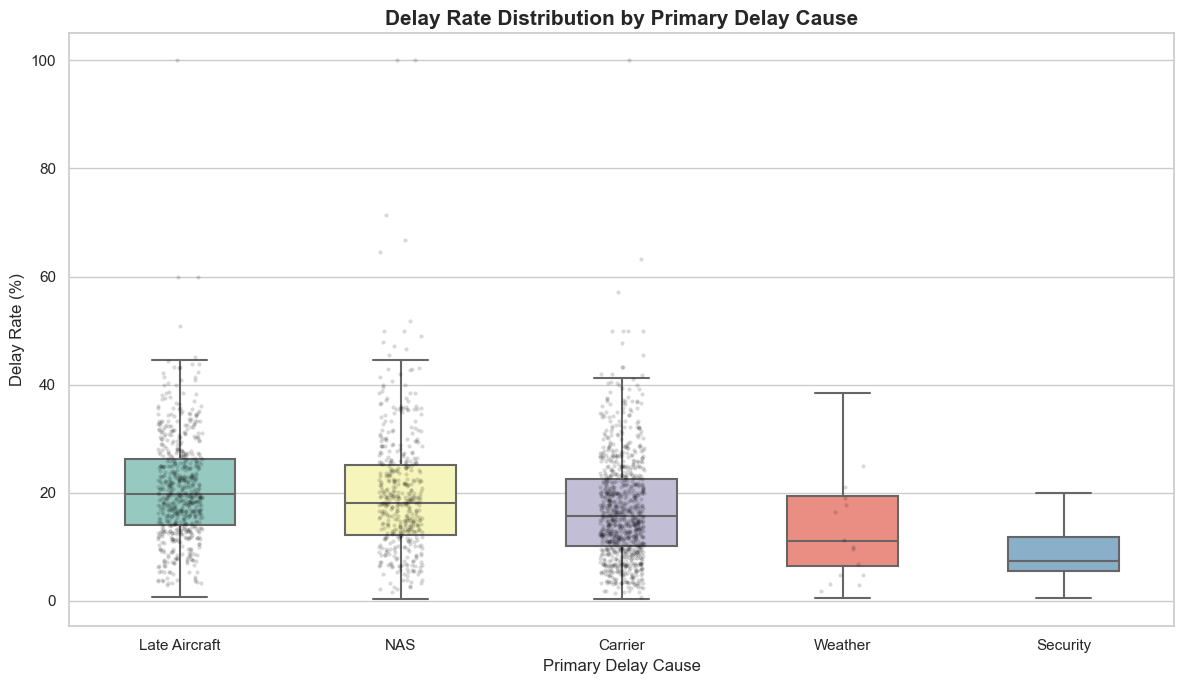


📌 INSIGHT — Boxplot by Cause:
  • WEATHER delays produce the WIDEST spread — hard to predict or control.
  • NAS & Late Aircraft have similar median delay rates (operational causes).
  • SECURITY has the narrowest range — rare but fairly uniform when they occur.


In [26]:
df_box = df[df['delay_rate'] > 0]  # remove zero-delay rows

plt.figure(figsize=(12, 7))
order = ['Late Aircraft', 'NAS', 'Carrier', 'Weather', 'Security']

sns.boxplot(
    data=df_box,
    x='dominant_cause',
    y='delay_rate',
    order=order,
    palette='Set3',
    showfliers=False,
    linewidth=1.5,
    width=0.5
)

sns.stripplot(
    data=df_box.sample(min(2000, len(df_box)), random_state=42),
    x='dominant_cause',
    y='delay_rate',
    order=order,
    color='black',
    alpha=0.15,
    size=3,
    jitter=True
)

plt.title('Delay Rate Distribution by Primary Delay Cause', fontsize=15, fontweight='bold')
plt.xlabel('Primary Delay Cause', fontsize=12)
plt.ylabel('Delay Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('plot_6_boxplot_by_cause.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT — Boxplot by Cause:")
print("  • WEATHER delays produce the WIDEST spread — hard to predict or control.")
print("  • NAS & Late Aircraft have similar median delay rates (operational causes).")
print("  • SECURITY has the narrowest range — rare but fairly uniform when they occur.")


In [ ]:
# ============================================================
#                  MY INSIGHTS & LEARNINGS
#           Airline Delay Data Pipeline Project
# ============================================================

# ----- WHAT IS A DATA PIPELINE? -----
# A data pipeline means taking raw data, cleaning it,
# and saving it in a usable format.
# In this project I followed 3 steps: Extract, Transform, Load (ETL)


# ----- STEP 1: EXTRACT -----
# I loaded the Airline_Delay_Cause.csv file using pandas read_csv()
# The dataset had 21 columns and thousands of rows
# Each row represents one airline at one airport in one month
# Columns include: arr_flights, arr_del15, arr_delay,
# carrier_ct, weather_ct, nas_ct, security_ct, late_aircraft_ct


# ----- STEP 2: TRANSFORM -----

# -- Missing Values --
# I found some columns had NaN (empty) values
# For number columns I filled them with 0
# because blank delay = no delay happened
# For text columns I filled with 'Unknown'
# so we don't lose those rows during analysis

# -- Removing Duplicates --
# I used drop_duplicates() to remove repeated rows
# Duplicate rows can make our averages wrong
# For example if one airline appears twice in same month
# it would count double which gives wrong results

# -- Fixing Data Types --
# year and month columns were stored as float (2019.0)
# I converted them to int (2019) using astype(int)
# I also created a month_name column like Jan, Feb, Mar
# This makes graphs easier to read

# -- Feature Engineering --
# I created 4 new columns from existing data:
#
# delay_rate = (arr_del15 / arr_flights) * 100
# --> tells us what % of flights got delayed
# --> more useful than just the count
#
# avg_delay_min = arr_delay / arr_del15
# --> tells average how many minutes each delayed flight was late
#
# cancel_rate = (arr_cancelled / arr_flights) * 100
# --> tells us what % of flights got cancelled
#
# dominant_cause = whichever delay cause had highest count
# --> tells us the main reason for delay in that record


# ----- STEP 3: LOAD -----
# After cleaning I saved the data to a new file
# called airline_delay_cleaned.csv using to_csv()
# I used index=False so row numbers are not saved in the file
# This clean file can now be used for future analysis


# ----- WHAT I LEARNED FROM THE VISUALIZATIONS -----

# From Correlation Heatmap:
# arr_del15 and arr_delay are very highly correlated
# meaning more delayed flights = more total delay minutes
# security_ct has almost no relation with other columns
# meaning security is a rare and independent cause

# From Distribution Plots:
# Most columns are right skewed
# meaning most flights have small delays
# but a few flights have very large delays (outliers)
# This is normal in real world transport data

# From Stacked Bar Chart (Delay Causes):
# Late Aircraft and NAS are the top 2 causes in every airline
# Security delays are barely visible in every airline
# This means most delays are operational not weather related

# From Monthly Trend Line:
# Delay rate is highest in June, July and December
# June July = summer holidays so more flights = more congestion
# December = winter holidays + cold weather causes delays
# September and October have the lowest delay rates
# So those are the best months to travel by flight

# From Airport Bar Chart:
# Small regional airports have higher delay rates
# because they have fewer runways and less staff
# Large airports like ATL and LAX handle more flights
# but their delay rate is actually lower due to better systems

# From Boxplot:
# Weather delays have the widest spread (most unpredictable)
# Security delays have the smallest spread (rare but consistent)
# This shows weather is the hardest delay type to control


# ----- OVERALL CONCLUSION -----
# The main reason for flight delays is Late Aircraft
# which means one delayed flight causes the next flight to delay too
# This is called a cascading delay effect
# Airlines can fix this by keeping buffer time between flights
#
# Weather delays are rare but when they happen they are severe
# Security is almost never a problem in this dataset
#
# The best time to fly is September or October
# The worst time is December or June/July
#
# This project helped me understand how raw messy data
# can be cleaned step by step and turned into useful insights
# using Python, pandas, matplotlib and seaborn

# ============================================================
print("Pipeline Complete! All insights noted above.")
# ============================================================
